
# Car Price Prediction - End-to-End Notebook

This notebook is aligned with the current app/training pipeline:
- Data: `data2.csv`
- Production model file: `models/car_price_pipeline.pkl`
- Metrics file: `models/training_metrics.json`

It covers:
1. Data loading and cleaning
2. EDA + plotting
3. Feature engineering
4. Training: Linear, Random Forest, LightGBM, XGBoost
5. Model selection rule: deploy best among LightGBM/XGBoost by MAE
6. Testing and sample predictions
7. Save deployed model + metrics


In [2]:

import os
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

import joblib

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 120)


In [3]:

# Paths
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "data2.csv")
MODELS_DIR = os.path.join(BASE_DIR, "models")
MODEL_PATH = os.path.join(MODELS_DIR, "car_price_pipeline.pkl")
METRICS_PATH = os.path.join(MODELS_DIR, "training_metrics.json")
CURRENT_YEAR = 2026

os.makedirs(MODELS_DIR, exist_ok=True)
print("DATA_PATH:", DATA_PATH)
print("MODEL_PATH:", MODEL_PATH)


DATA_PATH: c:\Users\Lenovo\Desktop\Web App\car_price_prediction\data2.csv
MODEL_PATH: c:\Users\Lenovo\Desktop\Web App\car_price_prediction\models\car_price_pipeline.pkl


## 1) Load Data

In [4]:

df = pd.read_csv(DATA_PATH, low_memory=False)
print(df.shape)
df.head(3)


(18134, 40)


,Make,Model,Manufacturing Year,Kilometers Driven,Fuel,Mileage,Owners,Transmission Type,RC Status,Loan Clearance,Accident History,Insurance Claims,Service Records,Body Panels,Rust,Glass Condition,Lights Condition,Tyres,Seats Condition,Electronics Condition,Smell,Engine Condition,Transmission Condition,Brakes Condition,Steering Condition,Suspension Condition,Battery Condition,AC Cooling,Rattling Noises,Engine Start,Idle Vibration,Acceleration Condition,Brakes Drive,Airbags Present,Airbags Count,Safety Systems,Selling Price,City,Color,Variant
0,Maruti,Alto,2015,120000,Petrol,19.7,1,Manual,Active,Cleared,Not Reported,NaN,Full,Poor,Poor,Average,Poor,Poor,Average,Poor,Poor,Poor,Poor,Poor,Poor,Poor,Average,Poor,Present,Yes,Poor,Poor,Poor,Yes,2,"Seat belts, ABS, EBD",42570,Hyderabad,Silver,VXI
1,Hyundai,Grand,2019,20000,Petrol,18.9,1,Manual,Active,Cleared,Reported,Single,Full,Average,Average,Good,Good,Average,Average,Average,Good,Average,Average,Good,Good,Average,Average,Average,Present,Yes,Good,Good,Average,Yes,2,"Seat belts, ABS, EBD",425472,Hyderabad,Grey,S
2,Hyundai,i20,2013,60000,Petrol,17.0,1,Manual,Active,Cleared,Reported,Single,Full,Poor,Poor,Average,Average,Poor,Poor,Average,Poor,Average,Poor,Poor,Average,Poor,Poor,Average,Present,Yes,Poor,Average,Poor,Yes,2,"Seat belts, ABS",104622,Ahmedabad,White,SX


In [5]:

print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18134 entries, 0 to 18133
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Make                    18134 non-null  object 
 1   Model                   18134 non-null  object 
 2   Manufacturing Year      18134 non-null  int64  
 3   Kilometers Driven       18134 non-null  int64  
 4   Fuel                    18134 non-null  object 
 5   Mileage                 18134 non-null  float64
 6   Owners                  18134 non-null  int64  
 7   Transmission Type       18134 non-null  object 
 8   RC Status               18134 non-null  object 
 9   Loan Clearance          18134 non-null  object 
 10  Accident History        18134 non-null  object 
 11  Insurance Claims        9067 non-null   object 
 12  Service Records         18134 non-null  object 
 13  Body Panels             18134 non-null  object 
 14  Rust                    18134 non-null

In [6]:

missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0].head(20)


Insurance Claims    9067
dtype: int64

## 2) Cleaning + Normalization

In [19]:

def normalize_categories(dataframe: pd.DataFrame) -> pd.DataFrame:
    out = dataframe.copy()
    for col in out.select_dtypes(include="object").columns:
        out[col] = out[col].astype(str).str.strip().replace({"nan": np.nan, "": np.nan})

    out["Accident History"] = out["Accident History"].replace({"Unknown": "Not Reported"})
    out["Insurance Claims"] = out["Insurance Claims"].replace({"None": np.nan, "Unknown": np.nan})
    return out

clean = normalize_categories(df)

numeric_base = ["Manufacturing Year", "Kilometers Driven", "Mileage", "Owners", "Airbags Count", "Selling Price"]
for col in numeric_base:
    clean[col] = pd.to_numeric(clean[col], errors="coerce")

clean = clean.dropna(subset=["Selling Price", "Manufacturing Year", "Kilometers Driven", "Mileage"]).copy()
clean = clean[clean["Selling Price"] > 10000].copy()

price_lo, price_hi = clean["Selling Price"].quantile([0.005, 0.995])
kms_lo, kms_hi = clean["Kilometers Driven"].quantile([0.005, 0.995])
clean["Selling Price"] = clean["Selling Price"].clip(price_lo, price_hi)
clean["Kilometers Driven"] = clean["Kilometers Driven"].clip(kms_lo, kms_hi)

print(clean.shape)


(18134, 40)


## 3) Feature Engineering

In [20]:

def add_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    out = dataframe.copy()
    out["Car_Age"] = (CURRENT_YEAR - out["Manufacturing Year"]).clip(lower=0, upper=35)
    out["kms_per_year"] = out["Kilometers Driven"] / np.maximum(out["Car_Age"], 1)

    quality_map = {"Poor": 0, "Average": 1, "Good": 2}
    condition_cols = [
        "Body Panels", "Rust", "Glass Condition", "Lights Condition", "Tyres",
        "Seats Condition", "Electronics Condition", "Smell", "Engine Condition",
        "Transmission Condition", "Brakes Condition", "Steering Condition",
        "Suspension Condition", "Battery Condition", "AC Cooling", "Idle Vibration",
        "Acceleration Condition", "Brakes Drive",
    ]

    out["condition_score"] = out[condition_cols].apply(lambda s: s.map(quality_map)).mean(axis=1)
    out["has_airbags"] = out["Airbags Present"].map({"Yes": 1, "No": 0})
    out["is_engine_start_ok"] = out["Engine Start"].map({"Yes": 1, "No": 0})
    out["rattling_present"] = out["Rattling Noises"].map({"Present": 1, "Occasional": 0})
    return out

feat = add_features(clean)
feat[["Car_Age", "kms_per_year", "condition_score", "has_airbags", "is_engine_start_ok", "rattling_present"]].head()


,Car_Age,kms_per_year,condition_score,has_airbags,is_engine_start_ok,rattling_present
0,11,10909.090909,0.166667,1,1,1
1,7,2857.142857,1.388889,1,1,1
2,13,4615.384615,0.388889,1,1,1
3,11,3363.636364,1.000000,1,1,0
4,8,3750.000000,1.000000,1,1,1


## 4) EDA + Plots

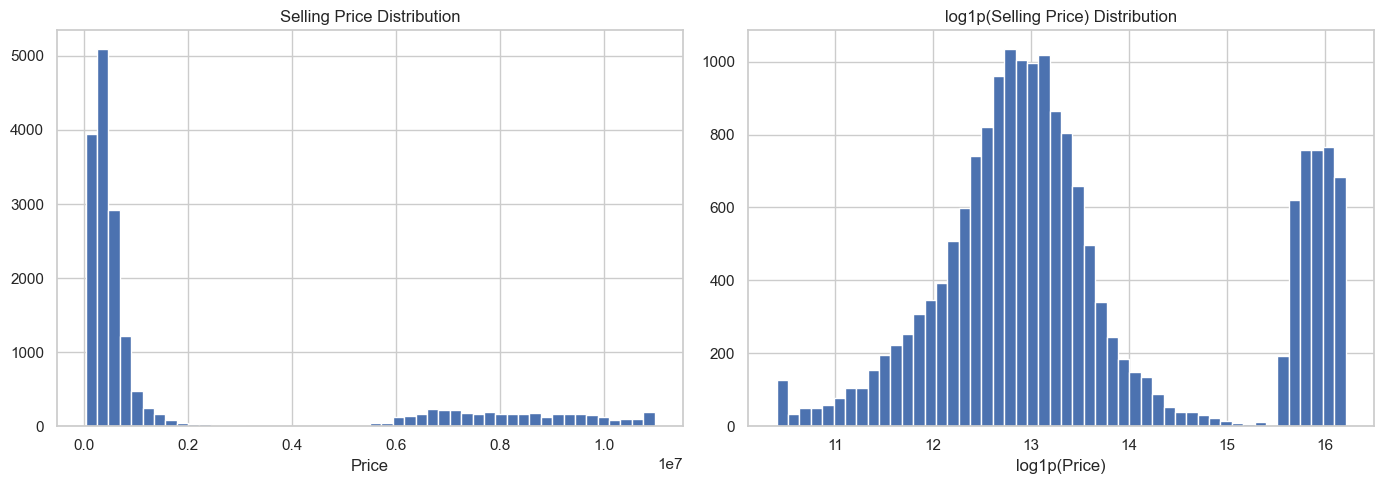

In [21]:

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(feat["Selling Price"], bins=50)
ax[0].set_title("Selling Price Distribution")
ax[0].set_xlabel("Price")

ax[1].hist(np.log1p(feat["Selling Price"]), bins=50)
ax[1].set_title("log1p(Selling Price) Distribution")
ax[1].set_xlabel("log1p(Price)")
plt.tight_layout()
plt.show()


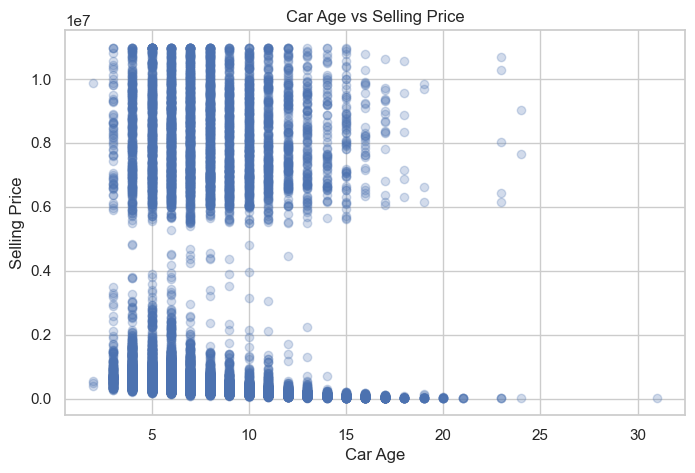

In [22]:

plt.figure(figsize=(8, 5))
plt.scatter(feat["Car_Age"], feat["Selling Price"], alpha=0.25)
plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()


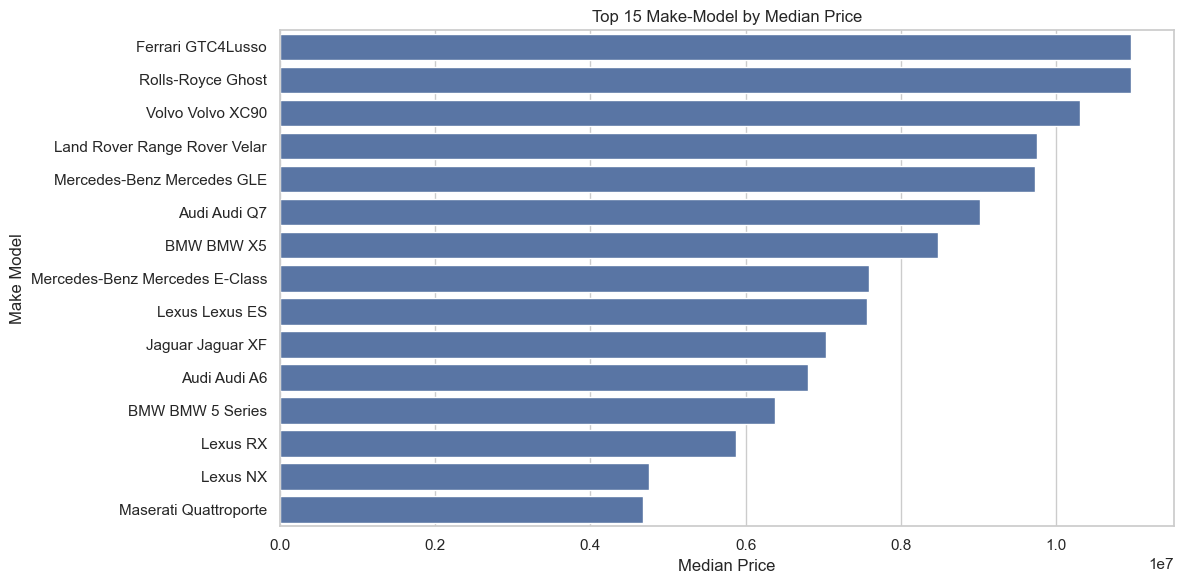

In [23]:

top_models = feat.groupby(["Make", "Model"])["Selling Price"].median().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_models.values, y=[f"{m} {n}" for m, n in top_models.index], orient="h")
plt.title("Top 15 Make-Model by Median Price")
plt.xlabel("Median Price")
plt.ylabel("Make Model")
plt.tight_layout()
plt.show()


## 5) Train/Test Split and Pipeline

In [24]:

feature_cols = [
    "Make", "Model", "Variant", "City", "Color", "Fuel", "Transmission Type", "RC Status",
    "Loan Clearance", "Accident History", "Insurance Claims", "Service Records", "Body Panels",
    "Rust", "Glass Condition", "Lights Condition", "Tyres", "Seats Condition",
    "Electronics Condition", "Smell", "Engine Condition", "Transmission Condition",
    "Brakes Condition", "Steering Condition", "Suspension Condition", "Battery Condition",
    "AC Cooling", "Rattling Noises", "Engine Start", "Idle Vibration", "Acceleration Condition",
    "Brakes Drive", "Airbags Present", "Safety Systems", "Manufacturing Year",
    "Kilometers Driven", "Mileage", "Owners", "Airbags Count", "Car_Age", "kms_per_year",
    "condition_score", "has_airbags", "is_engine_start_ok", "rattling_present"
]

X = feat[feature_cols].copy()
y_log = np.log1p(feat["Selling Price"].values)

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

for col in cat_cols:
    X[col] = X[col].astype(str).str.strip().replace({"nan": "Unknown", "": "Unknown"})

for col in num_cols:
    X[col] = pd.to_numeric(X[col], errors="coerce")
    X[col] = X[col].fillna(X[col].median())

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=10), cat_cols),
    ]
)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (14507, 45) Test: (3627, 45)


## 6) Train Multiple Models

In [13]:

candidates = {
    "linear": LinearRegression(),
    "random_forest": RandomForestRegressor(
        n_estimators=500, max_depth=None, min_samples_leaf=2, n_jobs=-1, random_state=42
    ),
    "lightgbm": LGBMRegressor(
        objective="regression",
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.2,
        random_state=42,
        n_jobs=-1,
    ),
}

if XGB_AVAILABLE:
    candidates["xgboost"] = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.2,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )

results = []
trained_pipelines = {}

for name, reg in candidates.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", reg)])
    pipe.fit(X_train, y_train_log)

    pred_log = pipe.predict(X_test)
    pred = np.expm1(pred_log)
    true = np.expm1(y_test_log)

    mae = float(mean_absolute_error(true, pred))
    rmse = float(np.sqrt(mean_squared_error(true, pred)))
    r2 = float(r2_score(true, pred))

    results.append({"model": name, "mae_holdout": mae, "rmse_holdout": rmse, "r2_holdout": r2})
    trained_pipelines[name] = pipe
    print(f"{name}: MAE={mae:,.2f} RMSE={rmse:,.2f} R2={r2:.4f}")


linear: MAE=635,647.56 RMSE=1,657,139.05 R2=0.7312
random_forest: MAE=194,136.68 RMSE=565,686.37 R2=0.9687
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 14507, number of used features: 249
[LightGBM] [Info] Start training from score 13.445576


c:\Users\Lenovo\Desktop\Web App\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


lightgbm: MAE=232,292.85 RMSE=606,451.82 R2=0.9640
xgboost: MAE=219,569.08 RMSE=580,686.51 R2=0.9670


In [14]:

results_df = pd.DataFrame(results).sort_values("mae_holdout", ascending=True).reset_index(drop=True)
results_df


,model,mae_holdout,rmse_holdout,r2_holdout
0,random_forest,194136.677550,5.656864e+05,0.968673
1,xgboost,219569.082070,5.806865e+05,0.966990
2,lightgbm,232292.852262,6.064518e+05,0.963995
3,linear,635647.555502,1.657139e+06,0.731165


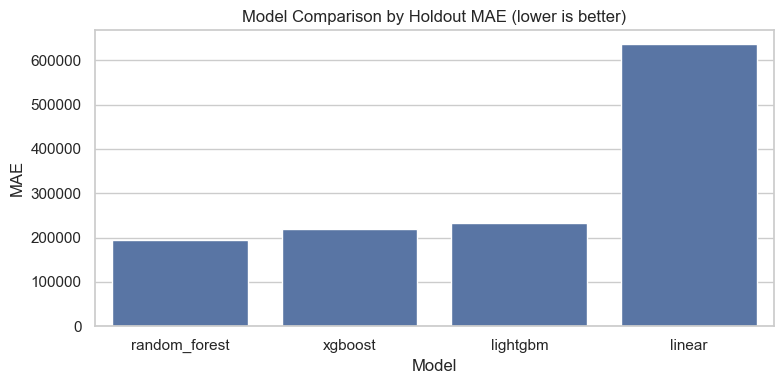

In [15]:

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="model", y="mae_holdout")
plt.title("Model Comparison by Holdout MAE (lower is better)")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


## 7) Deploy Selection Rule

In [16]:

best_overall = results_df.iloc[0]["model"]

preferred = results_df[results_df["model"].isin(["lightgbm", "xgboost"])]
if preferred.empty:
    raise RuntimeError("Neither LightGBM nor XGBoost is available.")

best_preferred = preferred.iloc[0]["model"]
deployed_pipe = trained_pipelines[best_preferred]

print("Best overall:", best_overall)
print("Deployed model (preferred set):", best_preferred)


Best overall: random_forest
Deployed model (preferred set): xgboost


## 8) Save Deployed Model + Metrics

In [17]:

joblib.dump(deployed_pipe, MODEL_PATH)

metrics = {
    "rows": int(len(feat)),
    "trained_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "xgboost_available": bool(XGB_AVAILABLE),
    "results_holdout": [
        {
            "model": str(r["model"]),
            "mae_holdout": round(float(r["mae_holdout"]), 2),
            "rmse_holdout": round(float(r["rmse_holdout"]), 2),
            "r2_holdout": round(float(r["r2_holdout"]), 4),
        }
        for _, r in results_df.iterrows()
    ],
    "best_overall_model": str(best_overall),
    "deployed_model": str(best_preferred),
    "deployment_rule": "best model among {'lightgbm','xgboost'} by holdout MAE",
    "saved_model_path": MODEL_PATH,
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Saved model:", MODEL_PATH)
print("Saved metrics:", METRICS_PATH)
metrics


Saved model: c:\Users\Lenovo\Desktop\Web App\car_price_prediction\models\car_price_pipeline.pkl
Saved metrics: c:\Users\Lenovo\Desktop\Web App\car_price_prediction\models\training_metrics.json


{'rows': 18134,
 'trained_at_utc': '2026-02-21T13:54:50+00:00',
 'xgboost_available': True,
 'results_holdout': [{'model': 'random_forest',
   'mae_holdout': 194136.68,
   'rmse_holdout': 565686.37,
   'r2_holdout': 0.9687},
  {'model': 'xgboost',
   'mae_holdout': 219569.08,
   'rmse_holdout': 580686.51,
   'r2_holdout': 0.967},
  {'model': 'lightgbm',
   'mae_holdout': 232292.85,
   'rmse_holdout': 606451.82,
   'r2_holdout': 0.964},
  {'model': 'linear',
   'mae_holdout': 635647.56,
   'rmse_holdout': 1657139.05,
   'r2_holdout': 0.7312}],
 'best_overall_model': 'random_forest',
 'deployed_model': 'xgboost',
 'deployment_rule': "best model among {'lightgbm','xgboost'} by holdout MAE",
 'saved_model_path': 'c:\\Users\\Lenovo\\Desktop\\Web App\\car_price_prediction\\models\\car_price_pipeline.pkl'}

## 9) Testing: Sample Predictions

In [18]:

sample = X_test.head(5).copy()
pred_log = deployed_pipe.predict(sample)
pred_price = np.expm1(pred_log)

actual_price = np.expm1(y_test_log[:5])

pd.DataFrame({
    "predicted_price": np.round(pred_price, 0).astype(int),
    "actual_price": np.round(actual_price, 0).astype(int),
})


,predicted_price,actual_price
0,257141,165945
1,812277,819874
2,7331813,7707834
3,12761899,9506814
4,374454,309200



## 10) Next Step for App

After running this notebook:
1. Restart Flask app (`app.py`) so it reloads `models/car_price_pipeline.pkl`.
2. Test in `/valuation` page.
